# 4주차 실습: 경복궁 위키 문서로 텍스트 RAG + SigLIP 이미지 검색

문서: 한국어 위키백과 「경복궁」 (본문 약 3.6만 자, 이미지 70장 안팎)

흐름
1. 위키 문서를 불러와서 잡음을 지우고 **txt로 저장해 고정**
2. 청킹 → 임베딩 → Chroma 벡터 DB
3. 기존 방식(벡터 검색 상위 4개)과 리랭킹 방식(후보 20개 → 리랭커 상위 4개)을 비교 (3주차와 동일)
4. **SigLIP으로 같은 문서의 이미지를 검색** → 텍스트 답변과 관련 사진을 함께 보여주기

> Colab 메뉴 `런타임 → 런타임 유형 변경 → T4 GPU`를 추천합니다.

In [1]:
!pip install -q -U langchain langchain-community langchain-openai langchain-text-splitters chromadb beautifulsoup4 sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.7/164.7 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.9/109.9 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.6/23.6 MB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/

In [2]:
import os
from google.colab import userdata

os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")
os.environ["USER_AGENT"] = "DRAG-study-bot/0.1"   # WebBaseLoader 경고 제거용

## 1. 위키 문서 불러오기 → 정리 → txt로 저장

위키는 수시로 편집되므로, 한 번 불러온 내용을 파일로 저장해 두고 이후에는 그 파일만 씁니다.
**`gyeongbokgung_wiki.txt`가 이미 있으면 이 셀은 다시 실행하지 않아도 됩니다.**

In [3]:
import re
import bs4
from langchain_community.document_loaders import WebBaseLoader

SOURCE_URL = "https://ko.wikipedia.org/wiki/경복궁"

loader = WebBaseLoader(
    web_paths=(SOURCE_URL,),
    bs_kwargs=dict(parse_only=bs4.SoupStrainer(id="mw-content-text")),  # 위키백과 본문 영역만(mw-content-text)
)
raw_text = loader.load()[0].page_content

text = raw_text
text = text.replace("[편집]", "")          # 소제목 옆 [편집] 링크 제거
text = re.sub(r"\[\d+\]", "", text)       # 각주 번호 [1], [23] 제거
text = re.sub(r"\[출처 필요\]", "", text)
cut = text.find("\n각주")                   # 문서 끝의 각주/참고문헌 목록 잘라내기
if cut > 0:
    text = text[:cut]
text = re.sub(r"\n{3,}", "\n\n", text).strip()

print("정리 전:", len(raw_text), "자 / 정리 후:", len(text), "자")
print("----- 마지막 300자 (각주 목록이 잘 잘렸는지 확인) -----")
print(text[-300:])

with open("gyeongbokgung_wiki.txt", "w", encoding="utf-8") as f:
    f.write(text)

/tmp/ipykernel_834/149521244.py:3: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader


정리 전: 36532 자 / 정리 후: 30276 자
----- 마지막 300자 (각주 목록이 잘 잘렸는지 확인) -----
근정전,광화문등만)
2017년 게임 - 오버워치 붉은 닭의 해 이벤트
2017년 애니메이션 - 스티븐 유니버스 근정문
2018년 드라마 - 황후의 품격 대한제국 황궁
2019 영화 - 천문: 하늘에 묻는다 조선의 정궁.
킹덤 - 창덕궁과 합성됨 (CG로 인정전이 근정전으로 바뀜)
사진

교통
● 수도권 전철 3호선 - 경복궁역
● 수도권 전철 5호선 - 광화문역
같이 보기
경복궁 자경전 십장생 굴뚝
경복궁타령
청와대
경복궁역
광화문역
광화문
흥례문
근정전
창덕궁
창경궁
경희궁
덕수궁
주해

↑ 임금이 거처하는 곳을 옮긴다는 뜻이다.


## 2. 저장한 txt로 기본 RAG 구성

In [4]:
from langchain_community.document_loaders import TextLoader

documents = TextLoader("gyeongbokgung_wiki.txt", encoding="utf-8").load()

In [5]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=400,      # 3.6만 자 문서 → 청크 100개 안팎
    chunk_overlap=80,
    separators=["\n\n", "\n", ". ", " ", ""]
)
chunks = text_splitter.split_documents(documents)

# txt에는 페이지 정보가 없으니 청크 번호를 출처로 사용
for i, c in enumerate(chunks):
    c.metadata["chunk_id"] = i

print("청크 수:", len(chunks))
print("===============================================================================================================================")
print(chunks[5].page_content)

청크 수: 121
그 해인 1395년 음력 10월 태조는 입궐하면서 정도전에게 새 궁궐과 주요 전각의 명칭을 지어 올리게 하였는데, 이때 경복궁의 명칭을 비롯하여 강녕전, 연생전, 경성전, 사정전, 근정전, 근정문, 정문(현재 광화문) 등 주요 건물의 명칭이 지어졌다. 정도전은 《시경》(詩經) 〈주아〉(周雅)에 나오는 “旣醉以酒 旣飽以德 君子萬年 介爾景福(기취이주 기포이덕 군자만년 개이경복)”에서 2자를 따서 “景福宮”(경복궁)이라고 지었다.


In [6]:
import shutil
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import Chroma

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

DB_DIR = "./chroma_gyeongbokgung"
shutil.rmtree(DB_DIR, ignore_errors=True)   # 다시 실행해도 중복이 쌓이지 않도록 매번 새로 만듦

vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    persist_directory=DB_DIR
)
print("벡터 DB 저장 수:", vectorstore._collection.count())  # 청크 수와 같아야 정상

벡터 DB 저장 수: 121


In [7]:
from langchain_core.prompts import ChatPromptTemplate
from langchain_openai import ChatOpenAI
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough, RunnableLambda

prompt = ChatPromptTemplate.from_template("""
당신은 제공된 문서를 기반으로 질문에 답변하는 어시스턴트입니다.
아래 제공된 컨텍스트만을 사용하여 질문에 답변하세요.
컨텍스트에 답변할 정보가 없으면 "해당 정보를 찾을 수 없습니다"라고 답하세요.
답변에 사용한 문서의 출처(청크 번호)를 명시하세요.

컨텍스트:
{context}

질문: {question}

답변:
""")

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

def format_docs_with_source(docs):
    return "\n\n".join(f"[청크 {d.metadata.get('chunk_id')}]\n{d.page_content}" for d in docs)

## 3. 기존 방식: 벡터 검색 상위 4개

In [8]:
retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": 4})

baseline_chain = (
    {"context": retriever | format_docs_with_source, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

## 4. 리랭킹 방식: 후보 20개 → Cross-encoder로 다시 채점 → 상위 4개

`BAAI/bge-reranker-v2-m3`는 한국어를 지원하는 다국어 cross-encoder입니다. 처음 실행 시 약 2GB를 내려받습니다.
`reranker.predict([(질문, 문서), ...])`가 발표에서 본 `[CLS] 질문 [SEP] 문서 → 점수` 구조입니다.

In [9]:
FIRST_STAGE_K = 20   # 1단계 후보 수
FINAL_TOP_N = 4       # 최종 문서 수 (기존 방식의 k=4와 맞춤)

base_retriever = vectorstore.as_retriever(search_type="similarity", search_kwargs={"k": FIRST_STAGE_K})

In [10]:
import torch
from sentence_transformers import CrossEncoder

device = "cuda" if torch.cuda.is_available() else "cpu"
reranker = CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512, device=device)
print("device:", device)

config.json:   0%|          | 0.00/795 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 2.27GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

...

sentencepiece.bpe.model: downloading bytes:           |  0.00B            

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

device: cuda


In [11]:
def rerank(query, docs, top_n=FINAL_TOP_N):
    pairs = [(query, d.page_content) for d in docs]      # 질문-문서 쌍
    scores = reranker.predict(pairs)                     # 쌍마다 관련성 점수
    ranked = sorted(zip(docs, scores), key=lambda x: x[1], reverse=True)
    results = []
    for doc, score in ranked[:top_n]:
        doc.metadata["rerank_score"] = float(score)
        results.append(doc)
    return results

def retrieve_and_rerank(query):
    return rerank(query, base_retriever.invoke(query))

rerank_chain = (
    {"context": RunnableLambda(retrieve_and_rerank) | format_docs_with_source, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

## 5. 검색 결과 전후 비교

"원래 몇 위였던 청크가 올라왔는지"와 "리랭킹에 걸린 시간"을 같이 봅니다.

In [12]:
import time

def _preview(text, n=70):
    return text[:n].replace("\n", " ")

def compare(query, top_n=FINAL_TOP_N):
    t0 = time.perf_counter()
    candidates = base_retriever.invoke(query)
    t1 = time.perf_counter()
    reranked = rerank(query, candidates, top_n)
    t2 = time.perf_counter()

    original_rank = {id(d): i + 1 for i, d in enumerate(candidates)}

    print(f"질문: {query}")
    print(f"벡터 검색({len(candidates)}개): {(t1 - t0) * 1000:.0f}ms / 리랭킹: {(t2 - t1) * 1000:.0f}ms")
    print(f"\n[리랭킹 전] 벡터 검색 상위 {top_n}")
    for i, d in enumerate(candidates[:top_n], 1):
        print(f"  {i}위 (청크 {d.metadata['chunk_id']}) {_preview(d.page_content)}")
    print(f"\n[리랭킹 후] 상위 {top_n}")
    for i, d in enumerate(reranked, 1):
        print(f"  {i}위 <- 원래 {original_rank[id(d)]}위 "
              f"(점수 {d.metadata['rerank_score']:.3f}, 청크 {d.metadata['chunk_id']}) {_preview(d.page_content)}")

In [13]:
test_questions = [
    "경복궁은 언제 누가 창건했나요?",
    "근정전은 어떤 용도로 쓰인 건물인가요?",
    "경회루는 어떤 건물인가요?",
    "임진왜란 이후 경복궁은 어떻게 되었고, 언제 다시 지어졌나요?",
]

for q in test_questions:
    compare(q)
    print("=" * 100)

질문: 경복궁은 언제 누가 창건했나요?
벡터 검색(20개): 863ms / 리랭킹: 2301ms

[리랭킹 전] 벡터 검색 상위 4
  1위 (청크 11) 경복궁은 태종, 세종을 거치면서 계속해서 전각이 더 지어지고 보완되었는데, 태종 11년(1411년)에는 명당수를 파서 이를 홍
  2위 (청크 48) 경복궁은 임진왜란(1592)으로 인해 창덕궁·창경궁과 함께 모두 불에 탄 것을 1867년에 흥선대원군이 다시 세웠다. 그러나 
  3위 (청크 24) 이 시기 경복궁은 비록 왕이 머무르는 거처로 사용되지는 않았지만, 아무나 쉽게 드나들 수 없는 공간으로 관리되었다. 1901년
  4위 (청크 1) 경복궁(景福宮, 영어: Gyeongbokgung Palace)은 대한민국 서울특별시 종로구 사직로에 위치한 조선 왕조의 법궁(

[리랭킹 후] 상위 4
  1위 <- 원래 14위 (점수 0.931, 청크 3) 1968년 광화문 복원을 시작으로 경복궁의 본모습을 되찾기 위한 각계의 관심과 노력이 증대되어, 1980년대 말부터 본격적인 
  2위 <- 원래 11위 (점수 0.863, 청크 4) 처음 새 궁궐을 지으려고 잡은 터는 고려 때의 남경이궁(南京 離宮) 자리였으나 너무 협소하여, 거기서 남쪽으로 조금 옮겨 지금
  3위 <- 원래 4위 (점수 0.716, 청크 1) 경복궁(景福宮, 영어: Gyeongbokgung Palace)은 대한민국 서울특별시 종로구 사직로에 위치한 조선 왕조의 법궁(
  4위 <- 원래 15위 (점수 0.676, 청크 97) 그러다 일제강점기인 1917년 화재로 사라진 창덕궁 내전 영역을 복구하기 위해 훼철되었고, 본 건물은 현재 창덕궁 경훈각이 되
질문: 근정전은 어떤 용도로 쓰인 건물인가요?
벡터 검색(20개): 1058ms / 리랭킹: 860ms

[리랭킹 전] 벡터 검색 상위 4
  1위 (청크 61) 근정전(勤政殿)근정전은 경복궁에서 문무백관의 조하(朝賀)를 비롯한 국가 의식을 거행하고, 외국 사신을 접견하던 정전이자 법전(
  2

## 6. 최종 답변 비교

In [14]:
for q in test_questions:
    print(f"질문: {q}\n")
    print("[기존]")
    print(baseline_chain.invoke(q))
    print("\n[리랭킹]")
    print(rerank_chain.invoke(q))
    print("=" * 100)

질문: 경복궁은 언제 누가 창건했나요?

[기존]
경복궁은 조선 왕조의 법궁으로, 태조 이성계에 의해 1395년에 창건되었습니다. (청크 1)

[리랭킹]
경복궁은 1392년 조선 왕조를 개창한 태조가 1394년에 창건하였습니다. (청크 3)
질문: 근정전은 어떤 용도로 쓰인 건물인가요?

[기존]
근정전은 경복궁에서 문무백관의 조하(朝賀)를 비롯한 국가 의식을 거행하고, 외국 사신을 접견하던 정전이자 법전(法殿)으로 사용되었습니다. (청크 61)

[리랭킹]
근정전은 경복궁에서 문무백관의 조하(朝賀)를 비롯한 국가 의식을 거행하고, 외국 사신을 접견하던 정전이자 법전(法殿)으로 사용되었습니다. (청크 61)
질문: 경회루는 어떤 건물인가요?

[기존]
경회루는 경복궁에 있는 누각으로, 국보 제224호입니다. 조선 시대에 나라의 경사가 있을 때 대연회를 베풀던 곳으로, 현재의 청와대 영빈관에 해당합니다. 현재의 경회루는 1867년에 새로 지은 건물로, 동쪽으로 치우친 네모난 섬 위에 지어진 2층 누각입니다. 원래 경회루는 경복궁 창건 당시 서쪽 습지에 세운 작은 누각이었으며, 태종 12년(1412년)에 연못을 넓히고 건물도 크게 완성하였습니다. (청크 94)

[리랭킹]
경회루는 경복궁에 있는 누각으로, 국보 제224호입니다. 조선 시대에 나라의 경사가 있을 때 대연회를 베풀던 장소로, 현재의 청와대 영빈관에 해당합니다. 경회루는 1867년에 새로 지어진 2층 누각 건물로, 정면 7칸, 측면 5칸의 규모를 가지고 있으며, 인공 연못 안의 섬 위에 세워져 있습니다. 원래는 경복궁 창건 당시 작은 누각이었으나, 태종 12년(1412년)에 연못을 넓히고 건물을 크게 완성하였습니다. (청크 94, 95)
질문: 임진왜란 이후 경복궁은 어떻게 되었고, 언제 다시 지어졌나요?

[기존]
임진왜란(1592) 이후 경복궁은 창덕궁·창경궁과 함께 모두 불에 탔습니다. 이후 1867년에 흥선대원군에 의해 다시 세워졌습니다. (청크 48)

[리랭킹]
임진왜란(1592) 이후 경

## 7. SigLIP으로 관련 이미지 찾기 (텍스트 → 이미지 검색)

텍스트 RAG는 그대로 두고, **같은 경복궁 문서의 이미지 중 질문과 관련된 사진을 SigLIP으로 찾아** 함께 보여줍니다.

흐름 (4회차 발표의 dual encoder 구조 그대로)
1. **인덱싱 (한 번만)**: 문서 이미지 수집 → SigLIP 이미지 인코더 → 정규화 → 저장
2. **검색 (질문마다)**: 질문만 SigLIP 텍스트 인코더로 벡터화 → 이미지 벡터와 코사인 유사도 → 상위 k개
3. **점수 해석**: `점수 = t × 유사도 + b` → `sigmoid` = "짝일 확률"

> 원래 SigLIP(`siglip-base-patch16-224`)은 영어 위주라 한국어 질문에 약합니다.
> 그래서 다국어 버전 **`google/siglip-base-patch16-256-multilingual`**(mSigLIP)을 씁니다.

In [15]:
!pip install -q sentencepiece protobuf

### 7-1. 문서 이미지 수집 → `/content/images`

이미지와 함께 **캡션**도 저장합니다. 캡션은 검색 결과가 맞는지 사람이 확인할 때 씁니다 (SigLIP 검색 자체는 이미지 픽셀만 봅니다).
캡션은 일반 그림(`figure`), 갤러리(`gallerytext`), 예전 형식(`thumbcaption`) 순서로 찾고, 없으면 `alt` 텍스트를 씁니다.

In [16]:
import os, json, requests
from urllib.parse import unquote
from bs4 import BeautifulSoup

SOURCE_URL = "https://ko.wikipedia.org/wiki/경복궁"
IMG_DIR = "/content/images"
META_PATH = os.path.join(IMG_DIR, "meta.json")
IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".gif")
HEADERS = {"User-Agent": "DRAG-study-bot/0.1 (educational project)"}   # 위키미디어는 User-Agent 필수

def find_caption(img):
    fig = img.find_parent("figure")
    if fig and fig.find("figcaption"):
        return fig.find("figcaption").get_text(" ", strip=True)
    gal = img.find_parent("li", class_="gallerybox")
    if gal and gal.find(class_="gallerytext"):
        return gal.find(class_="gallerytext").get_text(" ", strip=True)
    thumb = img.find_parent(class_="thumbinner") or img.find_parent(class_="thumb")
    if thumb and thumb.find(class_="thumbcaption"):
        return thumb.find(class_="thumbcaption").get_text(" ", strip=True)
    return img.get("alt") or ""

os.makedirs(IMG_DIR, exist_ok=True)
html = requests.get(SOURCE_URL, headers=HEADERS, timeout=20).text
content = BeautifulSoup(html, "html.parser").find(id="mw-content-text")

meta = json.load(open(META_PATH, encoding="utf-8")) if os.path.exists(META_PATH) else {}
seen = {v["source"] for v in meta.values()}
n_new = 0
for img in content.find_all("img"):
    if int(img.get("width") or 0) < 100:          # 아이콘, 추적용 픽셀 제외
        continue
    src = img["src"]
    src = "https:" + src if src.startswith("//") else src
    ext = os.path.splitext(unquote(src.split("?")[0]))[1].lower()
    if ext not in IMG_EXTS or src in seen:
        continue

    fname = f"img_{len(meta):03d}{ext}"           # 다시 실행해도 덮어쓰지 않도록 번호 이어가기
    r = requests.get(src, headers=HEADERS, timeout=20)
    if r.ok:
        with open(os.path.join(IMG_DIR, fname), "wb") as f:
            f.write(r.content)
        meta[fname] = {"caption": find_caption(img), "source": src}
        seen.add(src)
        n_new += 1

with open(META_PATH, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

print("새로 저장:", n_new, "/ 전체:", len(meta))
for k, v in list(meta.items())[:15]:
    print(f"  {k}: {v['caption'][:60]}")

새로 저장: 69 / 전체: 69
  img_000.jpg: 
  img_001.jpg: 임진왜란 이전의 모습을 반영한 것으로 추정되는 경복궁도 ( 서울역사박물관 )
  img_002.png: 중묘조서여관사연도 (1535년)에서 드러난 임진왜란 이전 근정전 앞뜰
  img_003.jpg: 임진왜란 이전 경복궁의 형상이 담긴 비변사계회도 (1550년, 명종 5년)
  img_004.jpg: 겸재 정선 의 〈경복궁도〉 (1754년경). 광화문 은 기단석축, 경회루 는 밑기둥만 남은 채 울창한 숲으로
  img_005.png: 1886년 오가와 카즈마사 가 촬영한 경복궁 전경
  img_006.jpg: 1906년의 근정전
  img_007.png: 1906년의 경회루
  img_008.jpg: 1929년 조선박람회 회장도
  img_009.jpg: 1965년 8월의 경복궁 전경. 국립박물관이 건설되지 않은 모습이다.
  img_010.jpg: 
  img_011.jpg: 
  img_012.jpg: 
  img_013.jpg: 신무문
  img_014.jpg: 흥례문.jpg


### 7-2. SigLIP 불러오기

`logit_scale`(t)와 `logit_bias`(b)는 발표에서 본 그 값입니다. 학습은 t = 10, b = −10에서 시작했고, 아래는 **학습이 끝난 뒤의 값**입니다.

In [17]:
import glob
import numpy as np
import torch
from PIL import Image
from transformers import AutoModel, AutoProcessor

device = "cuda" if torch.cuda.is_available() else "cpu"
SIGLIP_ID = "google/siglip-base-patch16-256-multilingual"

siglip = AutoModel.from_pretrained(SIGLIP_ID).to(device).eval()
siglip_processor = AutoProcessor.from_pretrained(SIGLIP_ID)

SIG_T = siglip.logit_scale.exp().item()
SIG_B = siglip.logit_bias.item()
print(f"device: {device} / 학습된 t = {SIG_T:.2f}, b = {SIG_B:.2f}")

config.json:   0%|          | 0.00/348 [00:00<?, ?B/s]

[transformers] Model config: bos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49406. This may result in unexpected behavior.
[transformers] Model config: eos_token_id must be `None` or an integer within the vocabulary (between 0 and 31999), got 49407. This may result in unexpected behavior.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.48GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

...

spiece.model: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 16.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

device: cuda / 학습된 t = 111.00, b = -12.89


### 7-3. 인덱싱: 이미지 벡터를 미리 한 번만 계산

텍스트는 반드시 `padding="max_length", max_length=64`로 넣어야 합니다. SigLIP이 그렇게 학습되어서, 다르게 넣으면 점수가 이상하게 나옵니다.

In [18]:
def _feat(out):
    # transformers 버전에 따라 텐서 또는 출력 객체로 나옴
    return out if isinstance(out, torch.Tensor) else out.pooler_output

@torch.no_grad()
def embed_images(paths, batch_size=16):
    if not paths:
        raise RuntimeError(f"{IMG_DIR}에 이미지가 없습니다. 7-1을 먼저 실행하세요.")
    feats = []
    for i in range(0, len(paths), batch_size):
        imgs = [Image.open(p).convert("RGB") for p in paths[i:i + batch_size]]
        inputs = siglip_processor(images=imgs, return_tensors="pt").to(device)
        f = _feat(siglip.get_image_features(**inputs))
        feats.append(torch.nn.functional.normalize(f, dim=-1).cpu())   # 길이 1로 정규화
    return torch.cat(feats).numpy()

@torch.no_grad()
def embed_text(text):
    inputs = siglip_processor(text=[text], padding="max_length", max_length=64,
                              truncation=True, return_tensors="pt").to(device)
    f = _feat(siglip.get_text_features(**inputs))
    return torch.nn.functional.normalize(f, dim=-1).cpu().numpy()[0]

image_paths = sorted(p for p in glob.glob(f"{IMG_DIR}/*") if p.lower().endswith(IMG_EXTS))
image_embs = embed_images(image_paths)
print("이미지 벡터:", image_embs.shape)   # (이미지 수, 768)

이미지 벡터: (69, 768)


### 7-4. 검색: 질문 → 관련 이미지

발표의 계산 그대로입니다. `유사도 → 점수(t·유사도 + b) → sigmoid → 짝일 확률`
캡션을 같이 출력하니, **찾아온 사진이 질문과 맞는지** 직접 확인해 보세요.

질문: 근정전
  1위 유사도 0.173 · 짝일 확률 99.8% · img_041.jpg · 


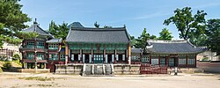

  2위 유사도 0.173 · 짝일 확률 99.8% · img_033.jpg · 자경전


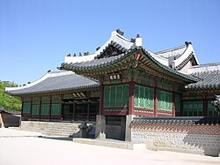

  3위 유사도 0.168 · 짝일 확률 99.7% · img_010.jpg · 


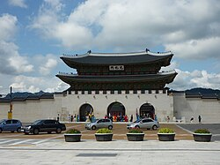

질문: 연못 위에 지어진 누각
  1위 유사도 0.126 · 짝일 확률 75.7% · img_061.jpg · 


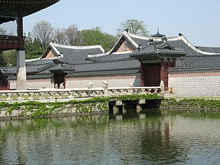

  2위 유사도 0.116 · 짝일 확률 51.1% · img_040.jpg · 향원정


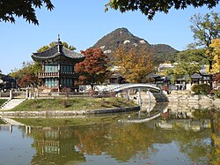

  3위 유사도 0.111 · 짝일 확률 35.1% · img_037.jpg · 경회루와 연못


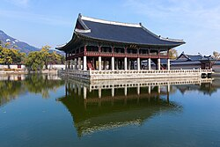

질문: 광화문
  1위 유사도 0.170 · 짝일 확률 99.8% · img_010.jpg · 


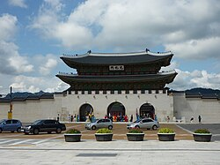

  2위 유사도 0.154 · 짝일 확률 98.6% · img_013.jpg · 신무문


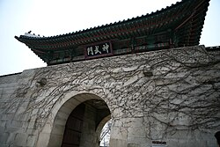

  3위 유사도 0.151 · 짝일 확률 98.0% · img_012.jpg · 


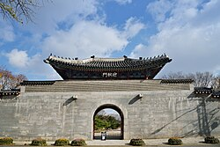

질문: 향원정
  1위 유사도 0.152 · 짝일 확률 98.2% · img_040.jpg · 향원정


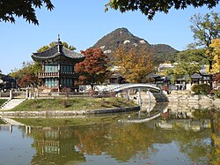

  2위 유사도 0.128 · 짝일 확률 79.4% · img_046.jpg · 


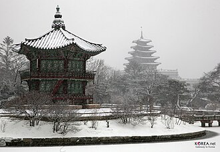

  3위 유사도 0.123 · 짝일 확률 68.4% · img_033.jpg · 자경전


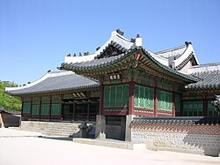

질문: 고양이 사진
  1위 유사도 0.104 · 짝일 확률 20.0% · img_052.jpg · 


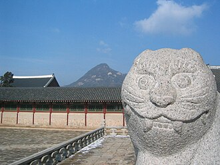

  2위 유사도 0.043 · 짝일 확률 0.0% · img_034.jpg · 


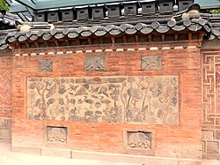

  3위 유사도 0.029 · 짝일 확률 0.0% · img_032.png · 


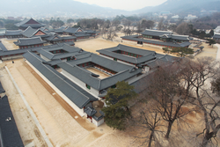

질문: 경복궁은 언제 누가 창건했나요?
  1위 유사도 0.135 · 짝일 확률 88.7% · img_065.jpg · 


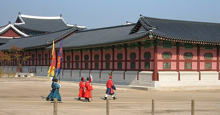

  2위 유사도 0.134 · 짝일 확률 87.6% · img_032.png · 


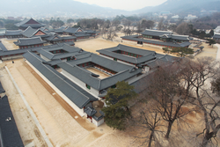

  3위 유사도 0.133 · 짝일 확률 87.3% · img_023.jpg · 강녕전


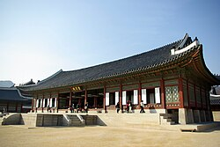

질문: 근정전은 어떤 용도로 쓰인 건물인가요?
  1위 유사도 0.072 · 짝일 확률 0.7% · img_032.png · 


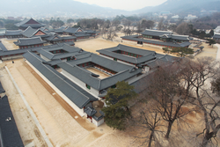

  2위 유사도 0.066 · 짝일 확률 0.4% · img_011.jpg · 


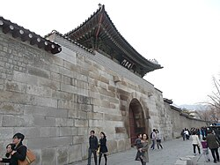

  3위 유사도 0.058 · 짝일 확률 0.2% · img_015.jpg · 


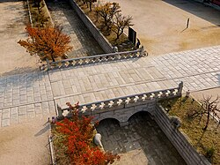

In [19]:
from IPython.display import display

def search_images(query, top_k=3):
    q = embed_text(query)
    sims = image_embs @ q                                # 둘 다 정규화했으니 내적 = 코사인 유사도
    probs = 1 / (1 + np.exp(-(SIG_T * sims + SIG_B)))    # 짝일 확률
    order = np.argsort(-sims)[:top_k]
    return [(image_paths[i], float(sims[i]), float(probs[i])) for i in order]

def show_image_results(query, top_k=3):
    print(f"질문: {query}")
    for rank, (path, sim, prob) in enumerate(search_images(query, top_k), 1):
        cap = meta.get(os.path.basename(path), {}).get("caption", "")
        print(f"  {rank}위 유사도 {sim:.3f} · 짝일 확률 {prob:.1%} · {os.path.basename(path)} · {cap[:50]}")
        img = Image.open(path).convert("RGB")
        img.thumbnail((220, 220))
        display(img)

image_questions = [
    "근정전",
    "연못 위에 지어진 누각",          # 경회루를 이름 없이 묘사
    "광화문",
    "향원정",
    "고양이 사진",                    # 관련 없는 질문: 확률이 낮아야 정상
] + test_questions[:2]

for q in image_questions:
    show_image_results(q)
    print("=" * 100)

**결과 볼 때 포인트**
- 순위는 유사도 순서와 확률 순서가 같습니다 (sigmoid는 단조증가).
- "연못 위에 지어진 누각"처럼 **이름 없이 묘사만 해도** 경회루 사진이 올라오면, SigLIP이 글자가 아니라 이미지 내용을 보고 찾는다는 뜻입니다.
- 짝일 확률은 생각보다 낮게 나오는 경우가 많습니다. 절대값보다 **관련 없는 질문("고양이 사진")과의 차이**를 보고, 앱의 "최소 짝일 확률" 기준을 정하세요.
- 위키 이미지에는 지도, 도면, 인물 초상처럼 질문과 무관한 것도 섞여 있습니다. 결과가 이상하면 `meta.json`의 캡션을 보고 원인을 확인해 보세요.

# 웹 chatbot 실행 코드

In [20]:
!pip install -q streamlit sentencepiece protobuf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 48.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 60.2 MB/s eta 0:00:00


In [21]:
%%writefile app.py
import os
import glob
import json
import time
import numpy as np
import streamlit as st
import torch
from PIL import Image
from transformers import AutoModel, AutoProcessor
from sentence_transformers import CrossEncoder
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_community.vectorstores import Chroma
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

DOC_PATH = "/content/gyeongbokgung_wiki.txt"
FIRST_STAGE_K = 10   # 1단계 후보 수
FINAL_TOP_N = 4      # LLM에 넘길 최종 청크 수

# ----- SigLIP 설정 -----
IMG_DIR = "/content/images"                              # 검색 대상 이미지 폴더
META_PATH = os.path.join(IMG_DIR, "meta.json")           # 이미지 캡션 (없어도 동작)
SIGLIP_ID = "google/siglip-base-patch16-256-multilingual"  # 한국어 쿼리용 다국어 SigLIP
IMG_EXTS = (".png", ".jpg", ".jpeg", ".webp", ".gif")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

st.set_page_config(page_title="경복궁 위키 챗봇", page_icon="🏯")


# ---------- 무거운 것들: 한 번만 만들고 재사용 ----------
@st.cache_resource
def load_vectorstore():
    docs = TextLoader(DOC_PATH, encoding="utf-8").load()
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=400, chunk_overlap=80, separators=["\n\n", "\n", ". ", " ", ""]
    )
    chunks = splitter.split_documents(docs)
    for i, c in enumerate(chunks):
        c.metadata["chunk_id"] = i
    return Chroma.from_documents(
        chunks, OpenAIEmbeddings(model="text-embedding-3-small"), collection_name="gyeongbokgung_app"
    )


@st.cache_resource
def load_reranker():
    return CrossEncoder("BAAI/bge-reranker-v2-m3", max_length=512, device=DEVICE)


@st.cache_resource
def load_chain():
    prompt = ChatPromptTemplate.from_template("""
당신은 제공된 문서를 기반으로 질문에 답변하는 어시스턴트입니다.
아래 제공된 컨텍스트만을 사용하여 질문에 답변하세요.
컨텍스트에 답변할 정보가 없으면 "해당 정보를 찾을 수 없습니다"라고 답하세요.
답변에 사용한 문서의 출처(청크 번호)를 명시하세요.

컨텍스트:
{context}

질문: {question}

답변:
""")
    llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)
    return prompt | llm | StrOutputParser()


@st.cache_resource
def load_siglip():
    model = AutoModel.from_pretrained(SIGLIP_ID).to(DEVICE).eval()
    processor = AutoProcessor.from_pretrained(SIGLIP_ID)
    return model, processor


def _feat(out):
    # transformers 버전에 따라 텐서 또는 출력 객체로 나옴
    return out if isinstance(out, torch.Tensor) else out.pooler_output


@st.cache_resource
def load_image_index():
    """인덱싱 단계: 폴더의 이미지를 한 번만 벡터로 바꿔 메모리에 저장"""
    model, processor = load_siglip()
    paths = sorted(p for p in glob.glob(f"{IMG_DIR}/*") if p.lower().endswith(IMG_EXTS))
    captions = json.load(open(META_PATH, encoding="utf-8")) if os.path.exists(META_PATH) else {}
    if not paths:
        return [], np.zeros((0, 1)), captions

    feats = []
    with torch.no_grad():
        for i in range(0, len(paths), 16):
            imgs = [Image.open(p).convert("RGB") for p in paths[i:i + 16]]
            inputs = processor(images=imgs, return_tensors="pt").to(DEVICE)
            f = _feat(model.get_image_features(**inputs))
            feats.append(torch.nn.functional.normalize(f, dim=-1).cpu())
    return paths, torch.cat(feats).numpy(), captions


# ---------- 검색 ----------
def retrieve(query, use_rerank):
    vs = load_vectorstore()
    if not use_rerank:
        docs = vs.similarity_search(query, k=FINAL_TOP_N)
        return [(d, None, i + 1) for i, d in enumerate(docs)]

    candidates = vs.similarity_search(query, k=FIRST_STAGE_K)
    scores = load_reranker().predict([(query, d.page_content) for d in candidates])
    ranked = sorted(
        [(d, float(s), i + 1) for i, (d, s) in enumerate(zip(candidates, scores))],
        key=lambda x: x[1], reverse=True,
    )
    return ranked[:FINAL_TOP_N]   # (문서, 리랭킹 점수, 원래 순위)


def search_images(query, top_k, min_prob):
    """검색 단계: 질문만 텍스트 인코더로 벡터화 → 저장된 이미지 벡터와 비교"""
    model, processor = load_siglip()
    paths, img_embs, captions = load_image_index()
    if not paths:
        return []

    with torch.no_grad():
        # SigLIP은 학습 때와 같이 64토큰 max_length 패딩을 해야 점수가 정상적으로 나옴
        inputs = processor(text=[query], padding="max_length", max_length=64,
                           truncation=True, return_tensors="pt").to(DEVICE)
        q = torch.nn.functional.normalize(_feat(model.get_text_features(**inputs)), dim=-1)
    q = q.cpu().numpy()[0]

    t = model.logit_scale.exp().item()      # 학습된 temperature
    b = model.logit_bias.item()             # 학습된 bias
    sims = img_embs @ q                     # 코사인 유사도
    probs = 1 / (1 + np.exp(-(t * sims + b)))   # 점수 = t·유사도 + b → sigmoid = 짝일 확률

    order = np.argsort(-sims)[:top_k]
    results = []
    for i in order:
        if probs[i] < min_prob:
            continue
        name = os.path.basename(paths[i])
        results.append({
            "path": paths[i],
            "caption": captions.get(name, {}).get("caption", "") or name,
            "sim": float(sims[i]),
            "prob": float(probs[i]),
        })
    return results


def show_sources(src):
    with st.expander(f"참고한 청크 · {src['mode']} · 검색 {src['search_ms']:.0f}ms"):
        for s in src["items"]:
            head = f"**청크 {s['chunk_id']}**"
            if s["score"] is not None:
                head += f" · 점수 {s['score']:.3f} · 원래 {s['orig_rank']}위"
            st.markdown(head)
            st.caption(s["preview"])


def show_images(img_src):
    st.markdown(f"**관련 이미지 (SigLIP)** · 검색 {img_src['search_ms']:.0f}ms")
    if not img_src["items"]:
        st.caption("기준을 넘는 관련 이미지가 없습니다.")
        return
    cols = st.columns(len(img_src["items"]))
    for col, it in zip(cols, img_src["items"]):
        with col:
            st.image(it["path"])
            st.caption(f"{it['caption'][:60]}\n\n유사도 {it['sim']:.3f} · 짝일 확률 {it['prob']:.1%}")


# ---------- 화면 ----------
st.title("🏯 경복궁 위키 챗봇")

with st.sidebar:
    use_rerank = st.toggle("Reranking 사용", value=True)
    st.caption(f"켜면 후보 {FIRST_STAGE_K}개 → 리랭커 상위 {FINAL_TOP_N}개\n\n끄면 벡터 검색 상위 {FINAL_TOP_N}개")
    st.divider()
    use_images = st.toggle("관련 이미지 찾기 (SigLIP)", value=True)
    img_top_k = st.slider("이미지 개수", 1, 5, 3)
    min_prob = st.slider("최소 짝일 확률", 0.0, 0.5, 0.0, 0.01,
                         help="0이면 상위 이미지를 모두 표시. 값을 보고 기준을 조정하세요.")
    st.caption(f"이미지 폴더: {IMG_DIR} · {len(load_image_index()[0])}장")
    if st.button("대화 초기화"):
        st.session_state.messages = []

if "messages" not in st.session_state:
    st.session_state.messages = []

# 지난 대화 다시 그리기 (Streamlit은 입력할 때마다 화면을 처음부터 다시 그림)
for m in st.session_state.messages:
    with st.chat_message(m["role"]):
        st.markdown(m["content"])
        if m.get("images"):
            show_images(m["images"])
        if m.get("sources"):
            show_sources(m["sources"])

if query := st.chat_input("경복궁에 대해 물어보세요"):
    st.session_state.messages.append({"role": "user", "content": query})
    with st.chat_message("user"):
        st.markdown(query)

    with st.chat_message("assistant"):
        with st.spinner("검색하고 답변을 만드는 중..."):
            t0 = time.perf_counter()
            results = retrieve(query, use_rerank)
            search_ms = (time.perf_counter() - t0) * 1000

            context = "\n\n".join(f"[청크 {d.metadata['chunk_id']}]\n{d.page_content}" for d, _, _ in results)
            reply = load_chain().invoke({"context": context, "question": query})

            img_src = None
            if use_images:
                t1 = time.perf_counter()
                img_items = search_images(query, img_top_k, min_prob)
                img_src = {"items": img_items, "search_ms": (time.perf_counter() - t1) * 1000}

        st.markdown(reply)
        if img_src is not None:
            show_images(img_src)
        sources = {
            "mode": "Reranking" if use_rerank else "벡터 검색만",
            "search_ms": search_ms,
            "items": [
                {"chunk_id": d.metadata["chunk_id"], "score": s, "orig_rank": r,
                 "preview": d.page_content[:400].replace("\n", " ")}
                for d, s, r in results
            ],
        }
        show_sources(sources)

    st.session_state.messages.append(
        {"role": "assistant", "content": reply, "sources": sources, "images": img_src}
    )


Writing app.py


In [22]:
!streamlit run app.py --server.port 8501 --server.headless true &> /content/streamlit.log &

In [23]:
!wget -q https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64 -O cloudflared && chmod +x cloudflared
!nohup ./cloudflared tunnel --url http://localhost:8501 > /content/cloudflared.log 2>&1 &
!sleep 8 && grep -o 'https://[a-z0-9-]*\.trycloudflare\.com' /content/cloudflared.log

https://investigate-begun-close-looking.trycloudflare.com
